In [1]:
!pip install kagglehub

In [2]:
import kagglehub
path = kagglehub.dataset_download("pkdarabi/diagnosis-of-diabetic-retinopathy")

print("Data loaded successfuly from KaggleHub. Path to dataset files:", path)
import os
os.listdir(path)

Using Colab cache for faster access to the 'diagnosis-of-diabetic-retinopathy' dataset.
Data loaded successfuly from KaggleHub. Path to dataset files: /kaggle/input/diagnosis-of-diabetic-retinopathy


['Diagnosis of Diabetic Retinopathy', 'retino']

In [3]:
base_dir = path
subdirs = [os.path.join(base_dir, d) for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
for subdir in subdirs:
    print(subdir)

ret_dir = os.path.join(path ,'retino')
print(ret_dir if os.path.isdir(ret_dir) else "Directory does not exist")

/kaggle/input/diagnosis-of-diabetic-retinopathy/Diagnosis of Diabetic Retinopathy
/kaggle/input/diagnosis-of-diabetic-retinopathy/retino
/kaggle/input/diagnosis-of-diabetic-retinopathy/retino


# Prepare the data

In [4]:
!pip install matplotlib
!matplotlib inline

/bin/bash: line 1: matplotlib: command not found


{'train': {'DR': 1050, 'No_DR': 1026}, 'valid': {'DR': 245, 'No_DR': 286}, 'test': {'DR': 113, 'No_DR': 118}}


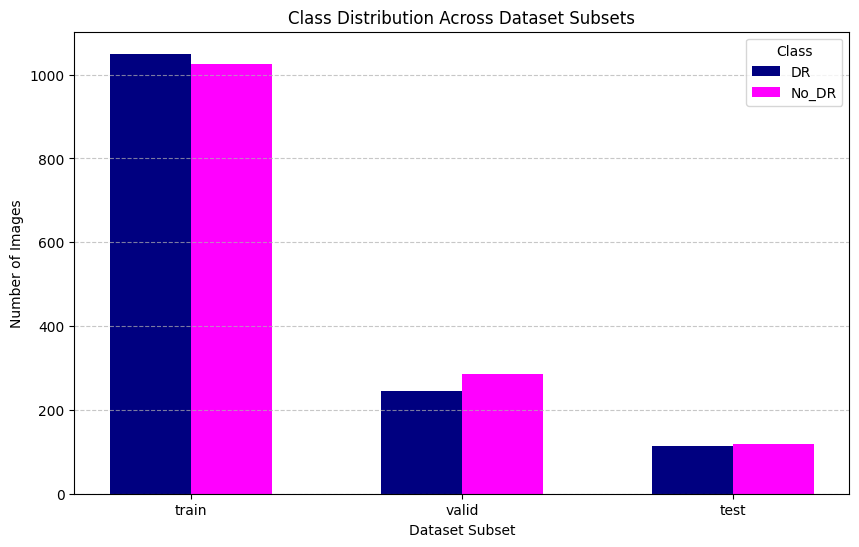

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict
from pathlib import Path
def get_dataset_stats(base_dir: Path )-> Dict[str, int]:
    """
    Returns a dictionary containing image counts per class for train, valid, and test sets.
    """
    stats: Dict[str, int]= {}
    for subset in ["train", "valid", "test"]:
        subset_path = os.path.join(base_dir, subset)
        if os.path.isdir(subset_path):
            stats[subset] = {}
            for class_name in os.listdir(subset_path):
                class_path = os.path.join(subset_path, class_name)
                if os.path.isdir(class_path):
                    num_images = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
                    stats[subset][class_name] = num_images
    return stats


def plot_class_distribution(stats: Dict[str, int])-> None:
    """
    Plots a grouped bar chart of class distributions for train, valid, and test sets with custom colors.
    """
    subsets = list(stats.keys())
    class_names = list(next(iter(stats.values())).keys())
    counts = {cls: [stats[subset].get(cls, 0) for subset in subsets] for cls in class_names}
    bar_width = 0.3
    x = np.arange(len(subsets))
    colors = ["navy", "magenta"]
    plt.figure(figsize=(10, 6))
    for i, (cls, values) in enumerate(counts.items()):
        plt.bar(x + i * bar_width, values, width=bar_width, label=cls, color=colors[i % len(colors)])
    plt.xlabel("Dataset Subset")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution Across Dataset Subsets")
    plt.xticks(x + bar_width / 2, subsets)
    plt.legend(title="Class")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
dataset_stats = get_dataset_stats(ret_dir)
print(dataset_stats)
plot_class_distribution(dataset_stats)

## Summary of MobileNet Architecture

mobile_net_archi.png

All imports

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import time
import csv
import math
from PIL import Image

from torch.utils.data import DataLoader, ConcatDataset, Subset
from torch.profiler import profile, ProfilerActivity, schedule, tensorboard_trace_handler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNet's inp size is 224*224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = os.path.join(ret_dir, 'train')
valid_dir = os.path.join(ret_dir, 'valid')
test_dir = os.path.join(ret_dir, 'test')

train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
valid_dataset = torchvision.datasets.ImageFolder(root=valid_dir, transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


num_train_batches = len(train_loader)
num_valid_batches = len(valid_loader)
num_test_batches = len(test_loader)

print(f"Number of batches in training set: {num_train_batches}")
print(f"Number of batches in validation set: {num_valid_batches}")
print(f"Number of batches in test set: {num_test_batches}")

print(f"Classes: {train_dataset.classes}")
print(f"Class-to-Index Mapping: {train_dataset.class_to_idx}")



Train dataset size: 2076
Validation dataset size: 531
Test dataset size: 231
Number of batches in training set: 65
Number of batches in validation set: 17
Number of batches in test set: 8
Classes: ['DR', 'No_DR']
Class-to-Index Mapping: {'DR': 0, 'No_DR': 1}


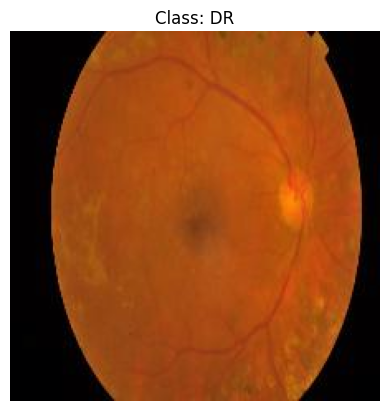

Batch size: torch.Size([32, 3, 224, 224])
Labels: tensor([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 1, 0, 0])


In [8]:
# here we check the loaders have been created successfully
image, label = train_dataset[1]
image = image.permute(1, 2, 0).numpy()  # change shape from (C, H, W) -> (H, W, C)
# Unnormalize
image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image = np.clip(image, 0, 1)
plt.imshow(image)
plt.title(f"Class: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
print(f"Batch size: {images.shape}")
print(f"Labels: {labels}")

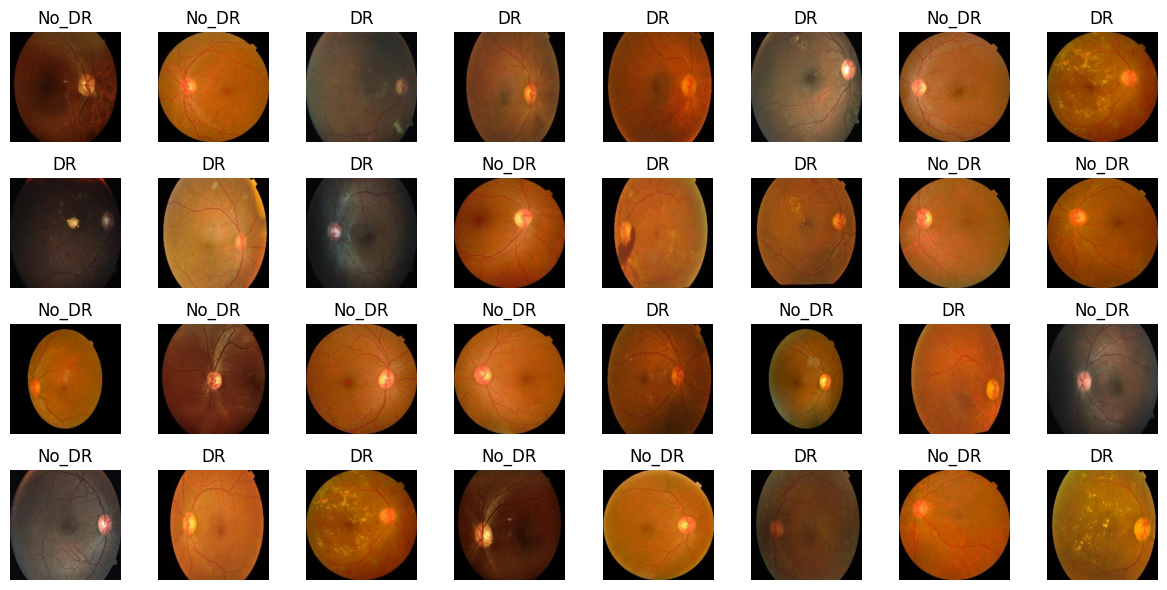

In [9]:
def show_batch(loader: DataLoader)-> None:
    """
    Check and visualise the training batch samples
    """
    dataiter = iter(loader)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))  # 32 = 4r,8c
    axes = axes.flatten()
    for img, lbl, ax in zip(images, labels, axes):
        img = img.permute(1, 2, 0).numpy()  # convert to HWC format
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(train_dataset.classes[lbl.item()])
        ax.axis("off")
    plt.tight_layout()
    plt.show()
show_batch(train_loader)


In [10]:
# 1. --- SETUP & DATASETS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device : {device}")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loading datasets
train_dataset = torchvision.datasets.ImageFolder(root=os.path.join(ret_dir, 'train'), transform=transform)
valid_dataset = torchvision.datasets.ImageFolder(root=os.path.join(ret_dir, 'valid'), transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root=os.path.join(ret_dir, 'test'), transform=transform)

# For K-Fold, we merge train and valid. Test remains separate for final evaluation.
full_train_pool = ConcatDataset([train_dataset, valid_dataset])

# Extract labels for Stratified split (to keep DR/No_DR ratio consistent)
# train_dataset.targets + valid_dataset.targets
all_labels = train_dataset.targets + valid_dataset.targets

Running on device : cuda


# Loading the pretrained model

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from torch.profiler import profile, ProfilerActivity, schedule, tensorboard_trace_handler
from sklearn.model_selection import StratifiedKFold
import numpy as np
import time
import pandas as pd

def initialize_model(device):
    """Resets the model architecture and weights for a fresh start."""
    # Using 'DEFAULT' for the latest weights as per current torchvision standards
    model = models.mobilenet_v2(weights='DEFAULT')
    model.classifier[1] = nn.Linear(in_features=model.last_channel, out_features=2)
    return model.to(device)


def run_kfold_training(full_train_pool, all_labels, k_folds=5, num_epochs=8, device='cpu'):
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

    # Master trackers for plotting
    all_folds_train_loss, all_folds_train_acc, all_folds_val_acc = [], [], []
    total_start_time = time.time()

    # Global Best Model Tracking
    best_overall_val_acc = 0.0
    best_model_state = None

    for fold, (train_ids, val_ids) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
        print(f"\n{'#'*20} STARTING FOLD {fold+1}/{k_folds} {'#'*20}")

        fold_train_loss, fold_train_acc, fold_val_acc = [], [], []

        # DataLoaders for this fold
        train_loader = DataLoader(Subset(full_train_pool, train_ids), batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
        valid_loader = DataLoader(Subset(full_train_pool, val_ids), batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

        # Reset model and optimizer
        mobilenet = initialize_model(device)
        optimizer = optim.Adam(mobilenet.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        # Profiler Setup (Fold 1 only)
        prof = None
        if fold == 0:
            prof = profile(
                activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA] if torch.cuda.is_available() else [ProfilerActivity.CPU],
                schedule=schedule(wait=1, warmup=1, active=3, repeat=1),
                on_trace_ready=tensorboard_trace_handler("./profiler_logs"),
                record_shapes=True, with_stack=True
            )
            prof.start()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()

            # --- TRAINING ---
            mobilenet.train()
            running_loss, correct, total = 0.0, 0, 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = mobilenet(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                if prof: prof.step()

                running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

            e_train_loss = running_loss / len(train_loader)
            e_train_acc = 100 * correct / total

            # --- VALIDATION ---
            mobilenet.eval()
            v_correct, v_total = 0, 0
            with torch.no_grad():
                for images, labels in valid_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = mobilenet(images)
                    _, predicted = torch.max(outputs, 1)
                    v_correct += (predicted == labels).sum().item()
                    v_total += labels.size(0)

            e_val_acc = 100 * v_correct / v_total

            # Track the best weights across all folds/epochs
            if e_val_acc > best_overall_val_acc:
                best_overall_val_acc = e_val_acc
                best_model_state = mobilenet.state_dict()

            fold_train_loss.append(e_train_loss)
            fold_train_acc.append(e_train_acc)
            fold_val_acc.append(e_val_acc)

            print(f"Fold {fold+1} | Ep {epoch+1} | Loss: {e_train_loss:.4f} | Train Acc: {e_train_acc:.2f}% | Val Acc: {e_val_acc:.2f}%")

        if prof:
            prof.stop()
            print("\nPROFILER EXCERPT (Fold 1):")
            print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=5))

        all_folds_train_loss.append(fold_train_loss)
        all_folds_train_acc.append(fold_train_acc)
        all_folds_val_acc.append(fold_val_acc)

    # Return the "Winner" and the data for plotting
    best_model = initialize_model(device)
    best_model.load_state_dict(best_model_state)

    print(f"\n{'='*30}\nOVERALL BEST VAL ACC: {best_overall_val_acc:.2f}%")
    return best_model, all_folds_train_loss, all_folds_train_acc, all_folds_val_acc

In [12]:
import torch.nn.functional as F

def evaluate_and_get_errors(model, test_loader, device, class_names):
    model.eval()
    all_labels, all_preds, all_probs, all_paths = [], [], [], []
    samples = test_loader.dataset.samples
    sample_idx = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            batch_size = labels.size(0)
            batch_paths = [samples[i][0] for i in range(sample_idx, sample_idx + batch_size)]
            sample_idx += batch_size

            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(predicted.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
            all_paths.extend(batch_paths)

    error_data = []
    for path, y_t, y_p, prob in zip(all_paths, all_labels, all_preds, all_probs):
        if y_t != y_p:
            error_data.append({
                'path': path, 'true_label': class_names[y_t],
                'pred_label': class_names[y_p], 'pred_confidence': float(prob[y_p])
            })

    test_acc = 100 * np.sum(np.array(all_labels) == np.array(all_preds)) / len(all_labels)
    return test_acc, pd.DataFrame(error_data)

In [13]:
def plot_rigorous_metrics(train_losses, train_accs, val_accs, num_epochs):
    plt.figure(figsize=(14, 5))
    epochs = range(1, num_epochs + 1)

    # Calculate Mean and Std Dev for shading
    v_acc_mean = np.mean(val_accs, axis=0)
    v_acc_std = np.std(val_accs, axis=0)

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, np.mean(train_losses, axis=0), label='Mean Train Loss', color='blue')
    plt.title('Cross-Validated Training Loss')
    plt.legend()

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, np.mean(train_accs, axis=0), label='Mean Train Acc', color='green')
    plt.plot(epochs, v_acc_mean, label='Mean Val Acc', color='red', lw=2)
    plt.fill_between(epochs, v_acc_mean - v_acc_std, v_acc_mean + v_acc_std, color='red', alpha=0.15)
    plt.title('Accuracy with Fold Variance')
    plt.legend()
    plt.show()

In [14]:
def show_misclassified_from_df(df, n=12, cols=4, random=True):
    """
    Plots images directly from the provided DataFrame.
    """
    if df is None or len(df) == 0:
        print("No errors to display.")
        return

    # 1. Pick images to show
    if random and len(df) > n:
        df_to_show = df.sample(n)
    else:
        df_to_show = df.head(min(len(df), n))

    # 2. Grid Setup
    count = len(df_to_show)
    actual_cols = min(count, cols)
    rows = math.ceil(count / actual_cols)

    fig, axes = plt.subplots(rows, actual_cols, figsize=(4*actual_cols, 4*rows))
    if count == 1: axes = [axes]
    else: axes = axes.flatten()

    # 3. Plotting Loop
    for ax, (_, row) in zip(axes, df_to_show.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        ax.imshow(img)
        title = f"True: {row['true_label']}\nPred: {row['pred_label']}\nConf: {row['pred_confidence']:.3f}"
        ax.set_title(title, fontsize=10, color='red', fontweight='bold')
        ax.axis("off")

    for ax in axes[count:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [15]:
# Set your hyperparams
NUM_EPOCHS = 8
K_FOLDS = 5

# Run the rigorous training
best_mobilenet, t_losses, t_accs, v_accs = run_kfold_training(
    full_train_pool=full_train_pool,
    all_labels=all_labels,
    k_folds=K_FOLDS,
    num_epochs=NUM_EPOCHS,
    device=device
)


#################### STARTING FOLD 1/5 ####################


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

Fold 1 | Ep 1 | Loss: 0.3089 | Train Acc: 89.64% | Val Acc: 95.02%
Fold 1 | Ep 2 | Loss: 0.1106 | Train Acc: 97.03% | Val Acc: 95.40%
Fold 1 | Ep 3 | Loss: 0.0599 | Train Acc: 98.03% | Val Acc: 95.98%
Fold 1 | Ep 4 | Loss: 0.0370 | Train Acc: 98.85% | Val Acc: 95.98%
Fold 1 | Ep 5 | Loss: 0.0245 | Train Acc: 99.33% | Val Acc: 96.55%
Fold 1 | Ep 6 | Loss: 0.0208 | Train Acc: 99.42% | Val Acc: 96.36%
Fold 1 | Ep 7 | Loss: 0.0157 | Train Acc: 99.42% | Val Acc: 96.55%
Fold 1 | Ep 8 | Loss: 0.0154 | Train Acc: 99.52% | Val Acc: 97.13%

PROFILER EXCERPT (Fold 1):
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
---------------------------------------

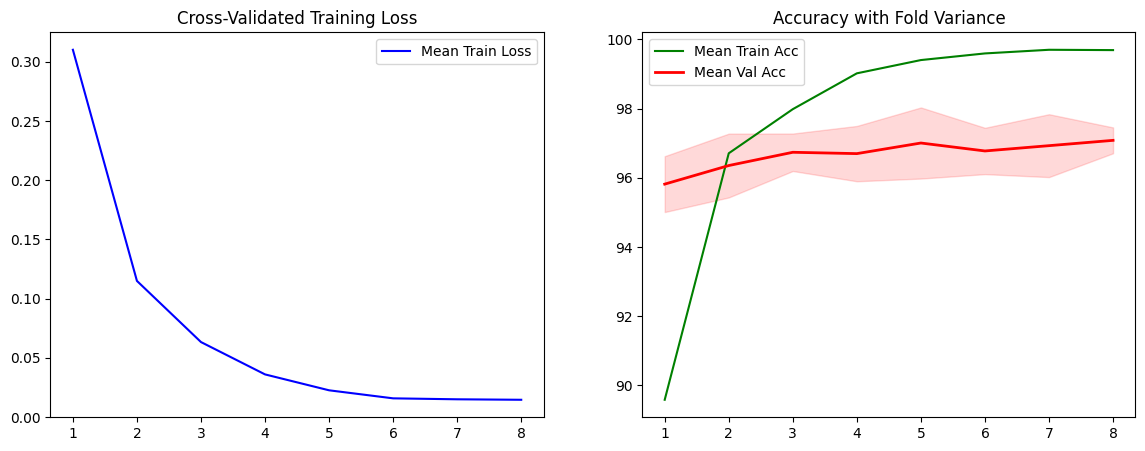

In [16]:
# Plot the results
plot_rigorous_metrics(t_losses, t_accs, v_accs, num_epochs=NUM_EPOCHS)

In [17]:
class_names = train_dataset.classes
# Run final evaluation
test_accuracy, df_errors = evaluate_and_get_errors(
    model=best_mobilenet,
    test_loader=test_loader,
    device=device,
    class_names=class_names
)

print(f"\nFinal Accuracy on Held-out Test Set: {test_accuracy:.2f}%")


Final Accuracy on Held-out Test Set: 96.54%


In [18]:
display(df_errors.head())

,path,true_label,pred_label,pred_confidence
0,/kaggle/input/diagnosis-of-diabetic-retinopath...,DR,No_DR,0.739713
1,/kaggle/input/diagnosis-of-diabetic-retinopath...,DR,No_DR,0.967631
2,/kaggle/input/diagnosis-of-diabetic-retinopath...,DR,No_DR,0.628375
3,/kaggle/input/diagnosis-of-diabetic-retinopath...,DR,No_DR,0.999264
4,/kaggle/input/diagnosis-of-diabetic-retinopath...,DR,No_DR,0.999561


In [19]:
print(f"Number of misclassified images: {len(df_errors)}")

Number of misclassified images: 8


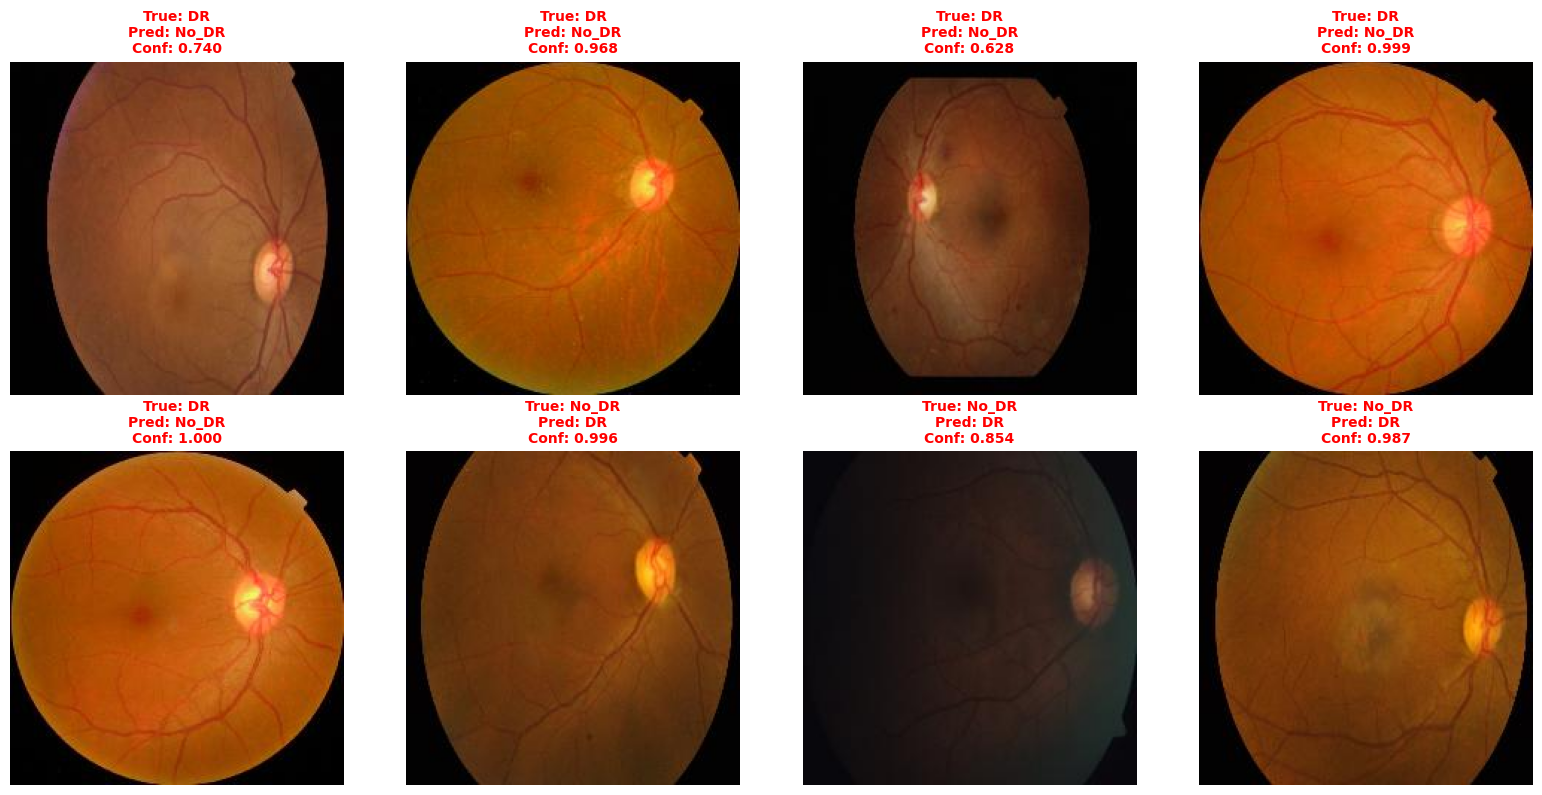

In [20]:
# Visualize the top 12 errors
show_misclassified_from_df(df_errors, n=12, cols=4, random=True)